In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/manufacturing.csv')

In [3]:
df

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [4]:
df.shape

(3957, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


In [8]:
df.columns

Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric',
       'Quality Rating'],
      dtype='object')

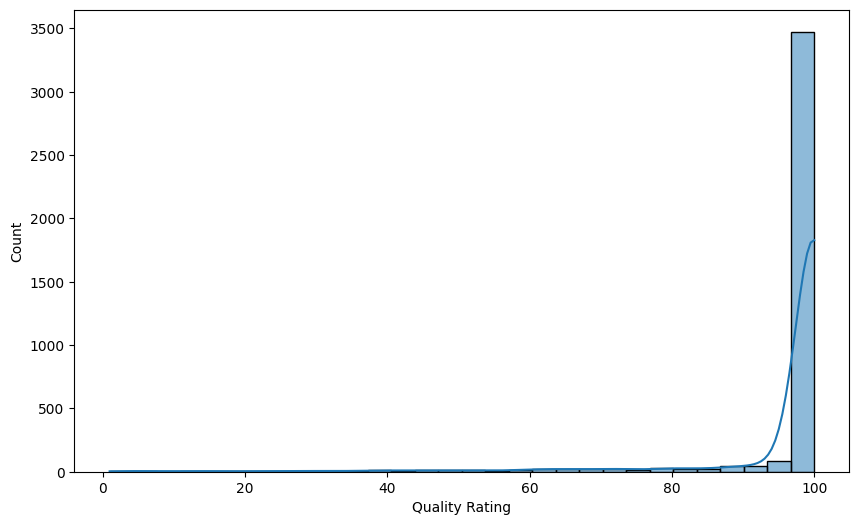

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['Quality Rating'], kde = True , bins = 30)
plt.show()

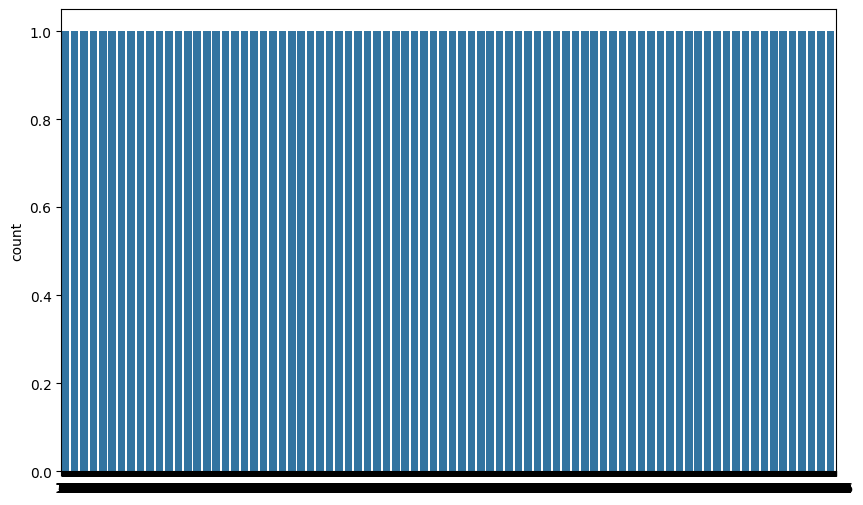

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(df['Quality Rating'])
plt.show()

In [14]:
df.isnull().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


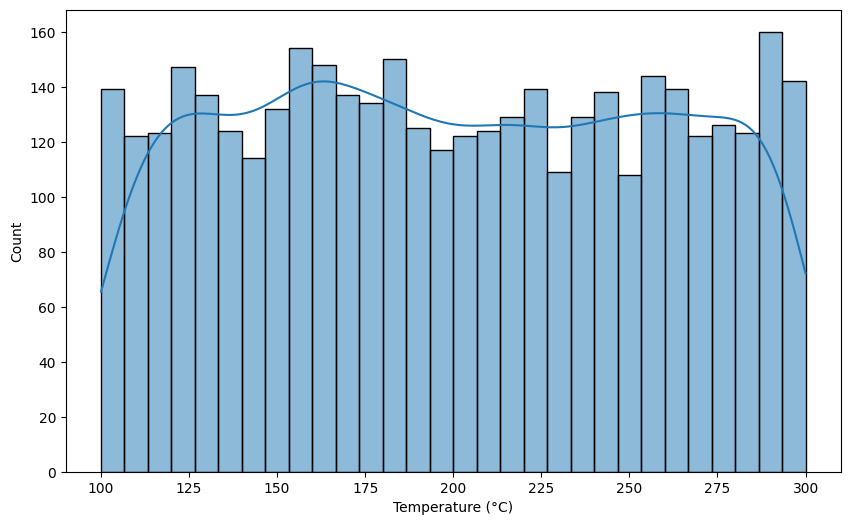

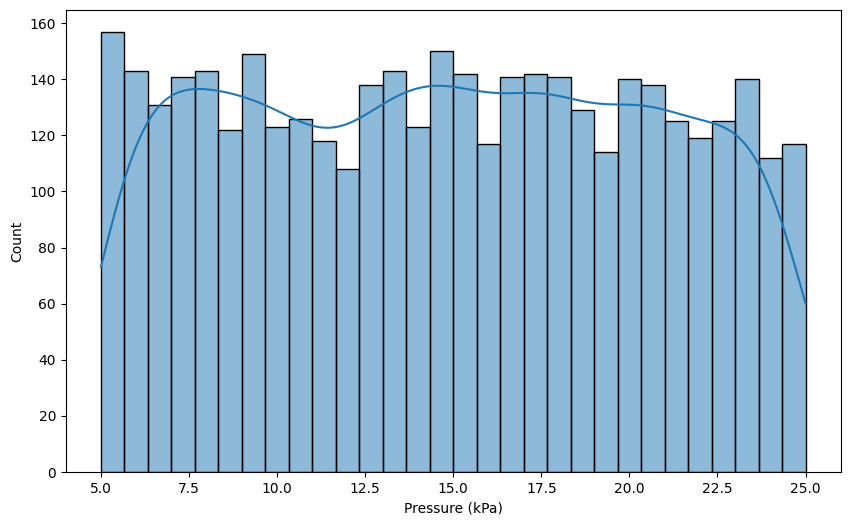

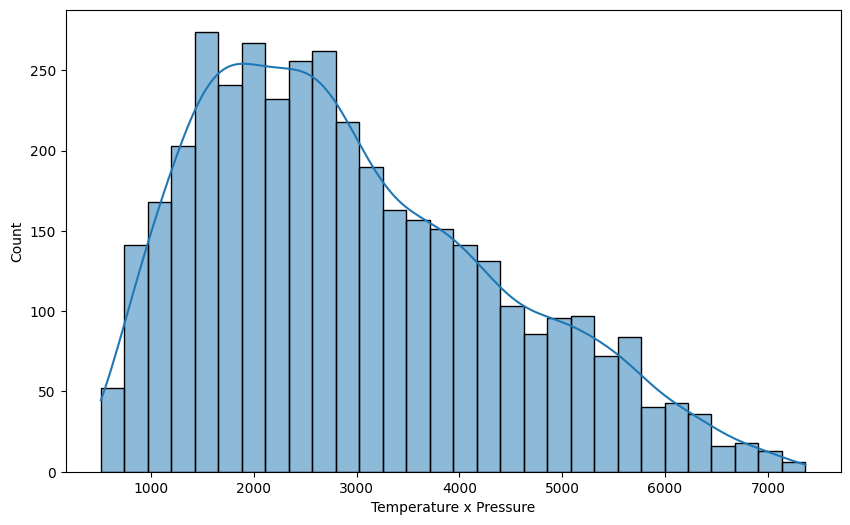

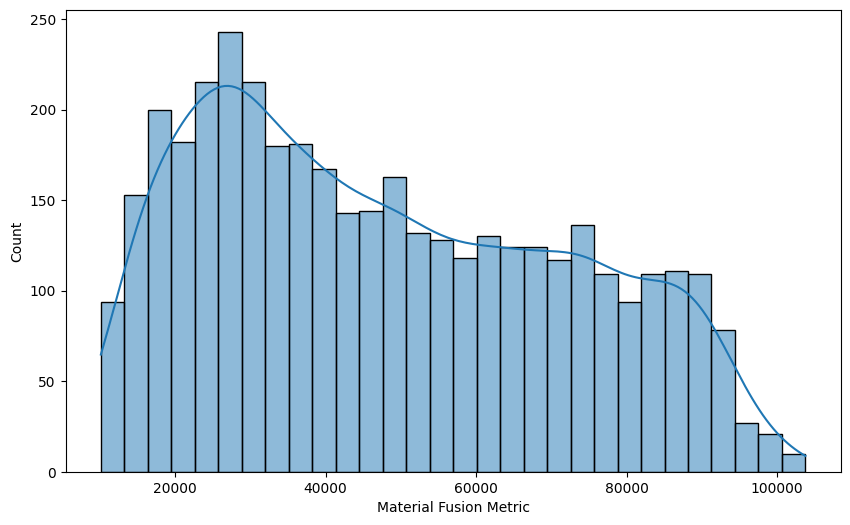

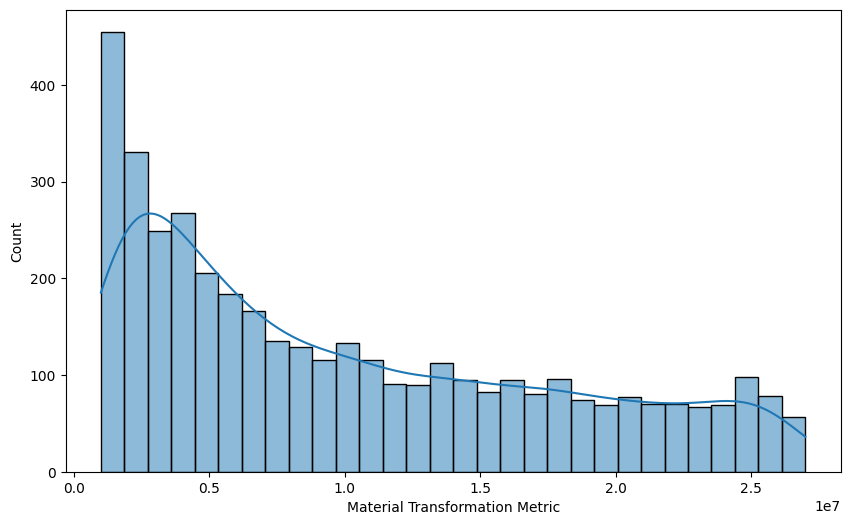

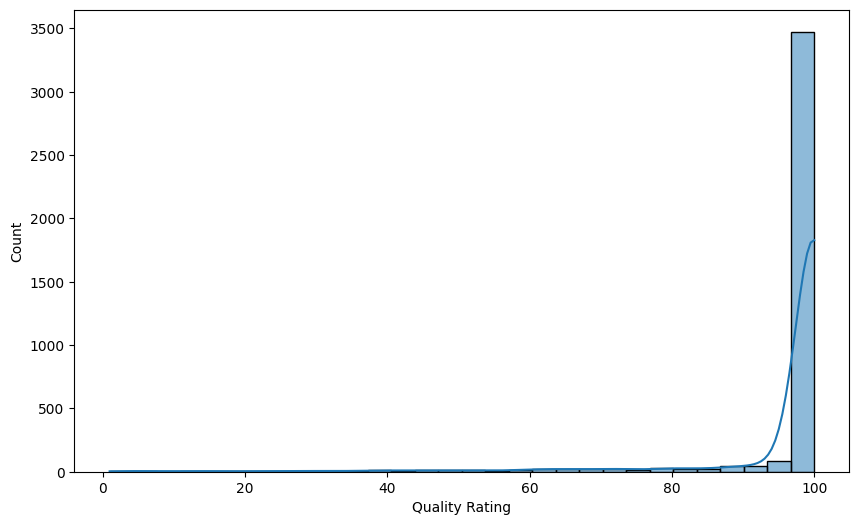

In [15]:
for col in df.columns:
  plt.figure(figsize=(10,6))
  sns.histplot(df[col], kde = True , bins = 30)
plt.show()

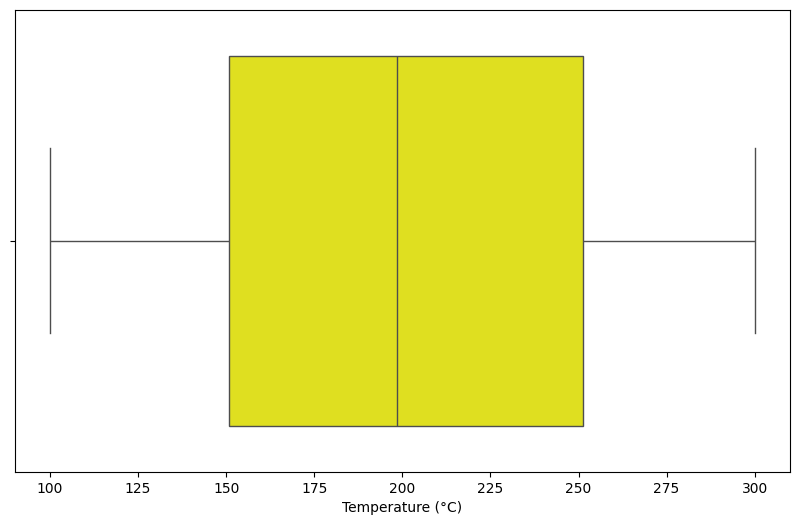

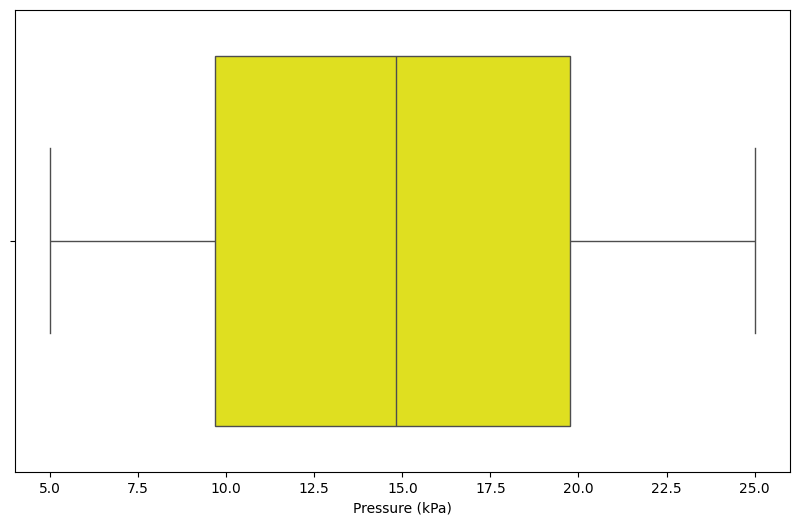

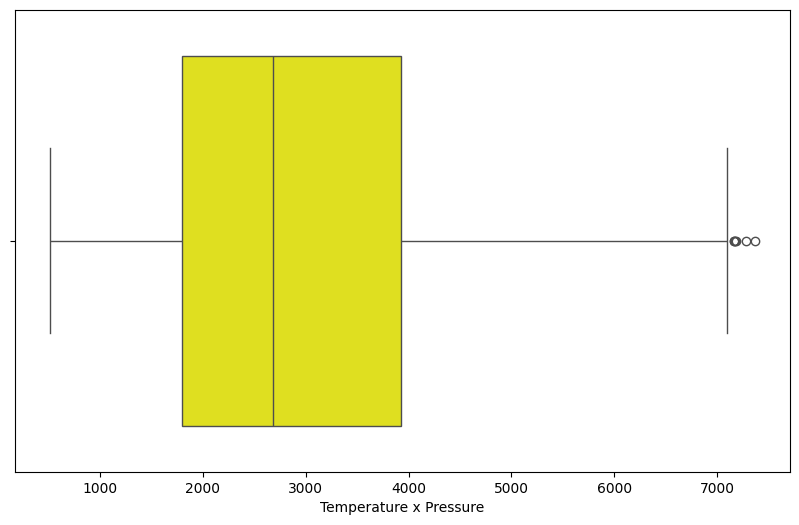

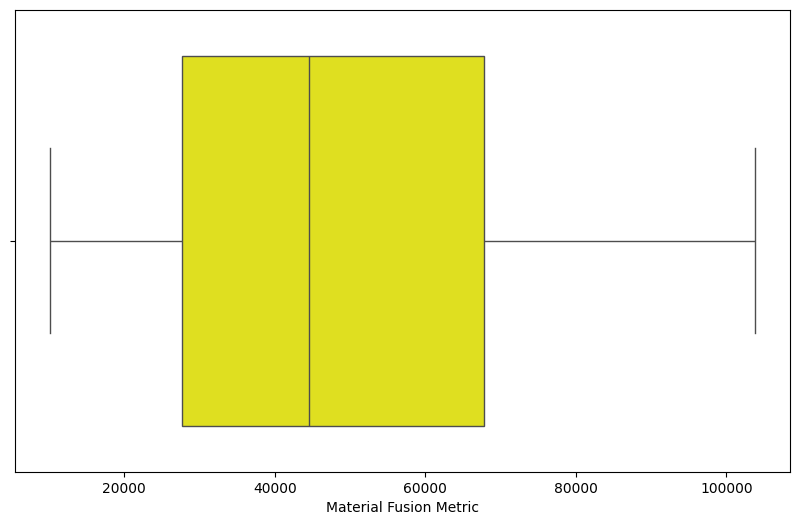

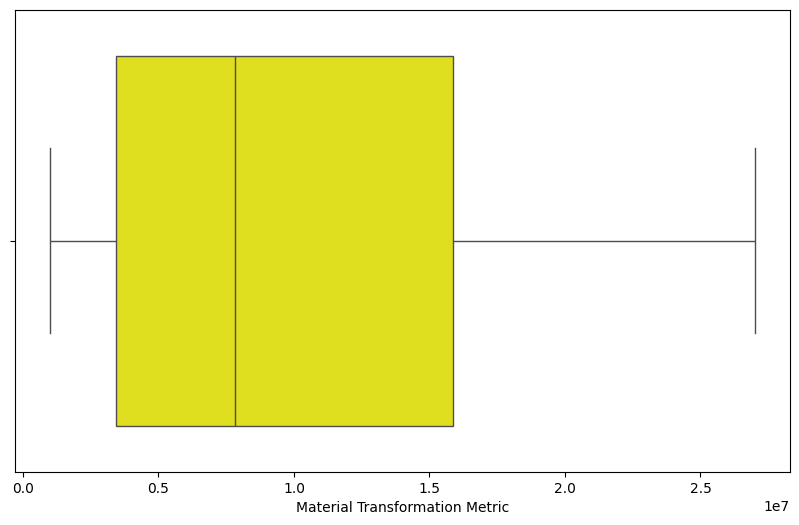

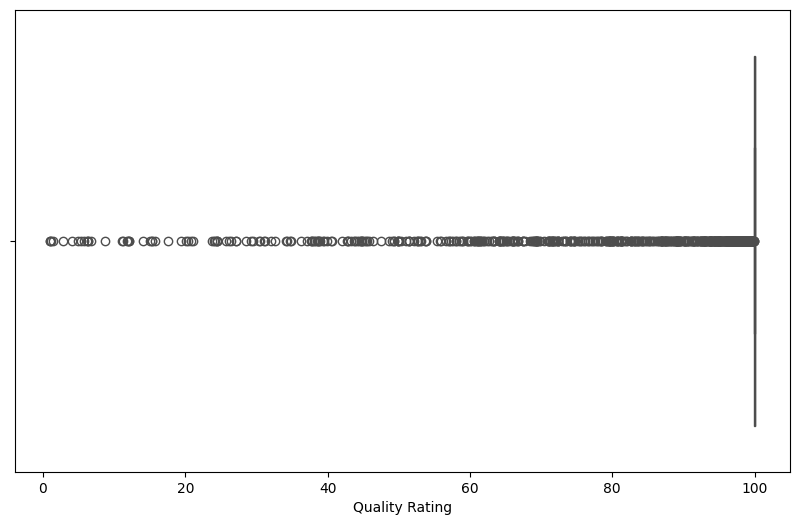

In [17]:
for col in df.columns:
  plt.figure(figsize=(10 , 6))
  sns.boxplot(x = df[col] , color='yellow')
plt.show()

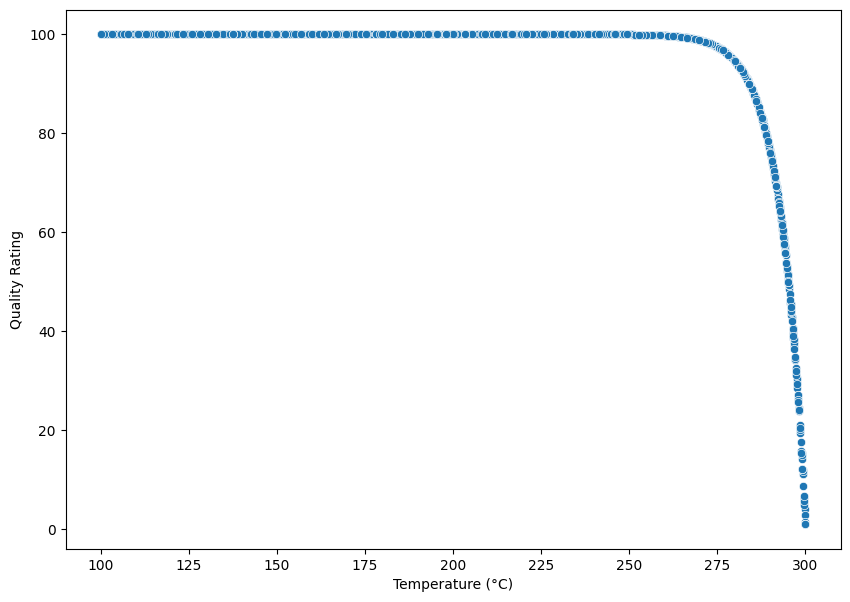

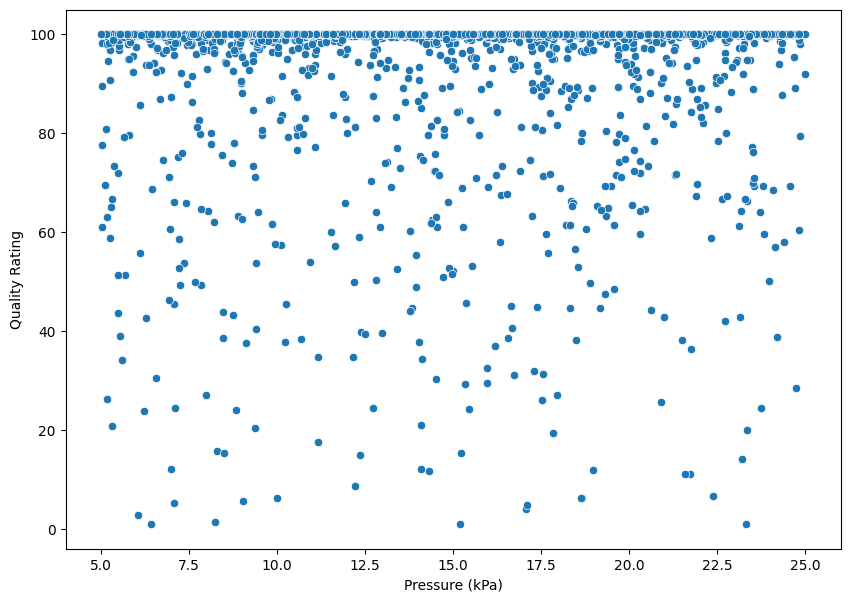

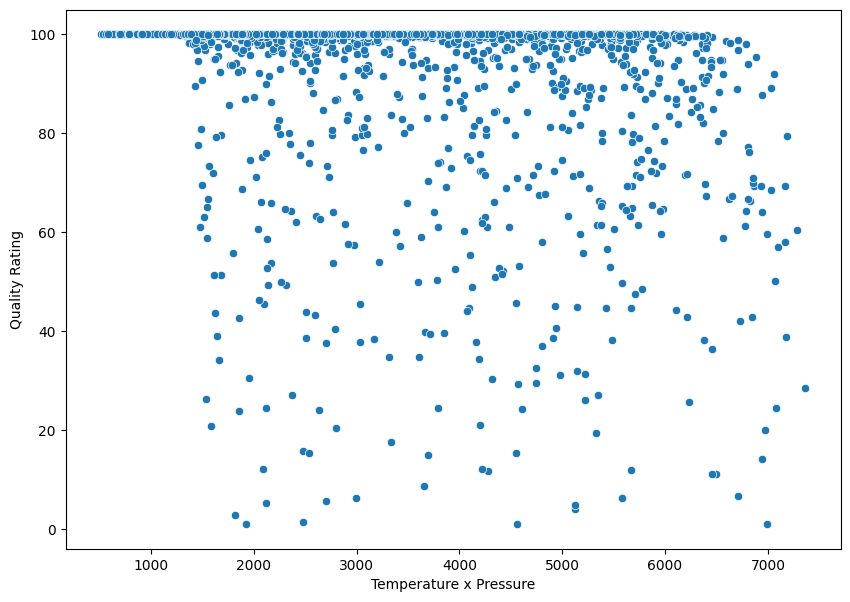

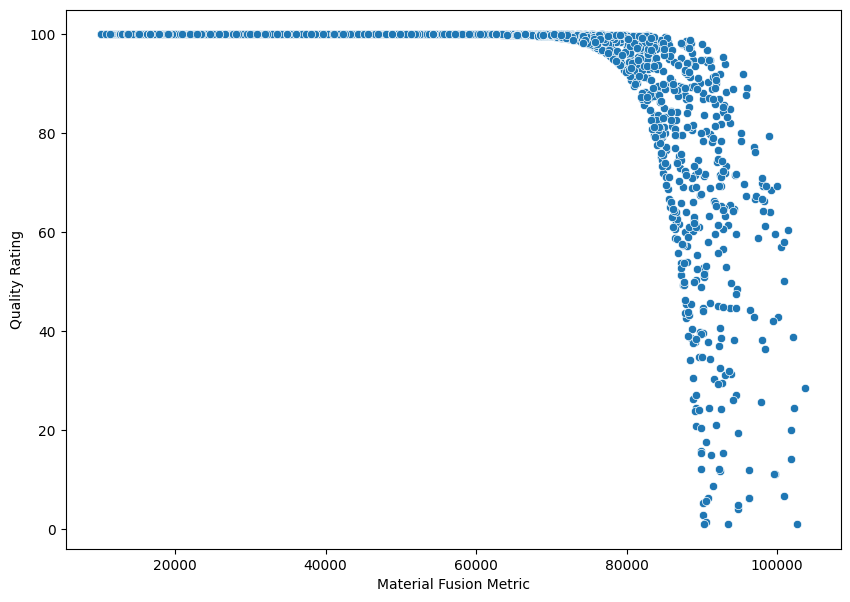

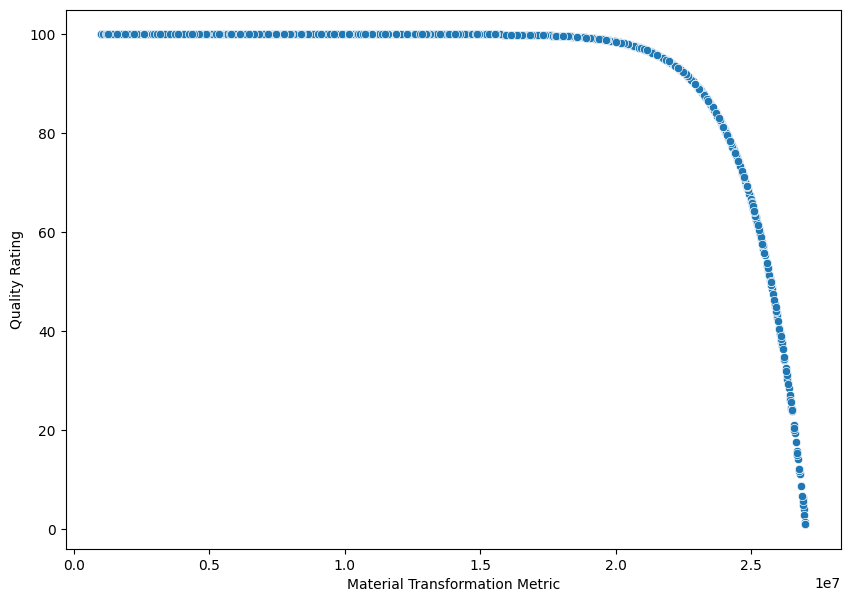

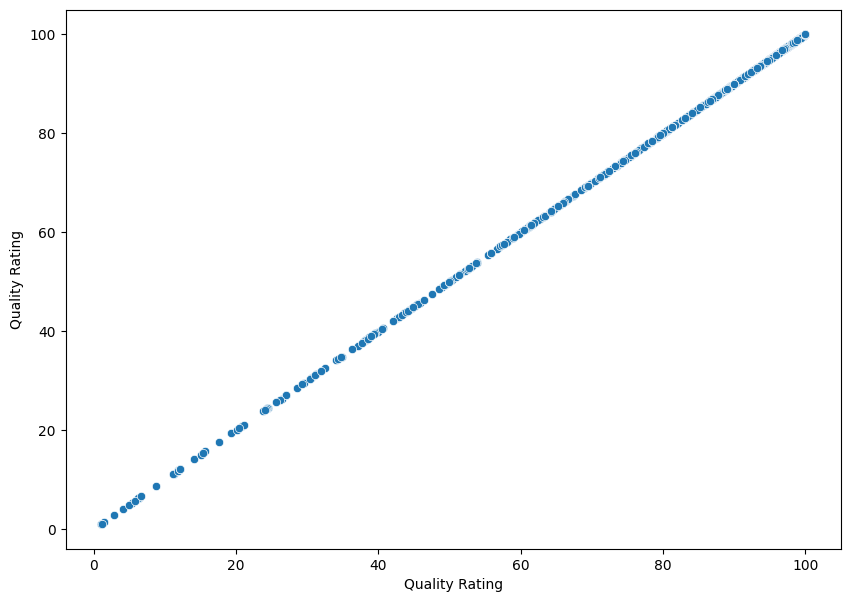

In [20]:
for col in df.columns:
  plt.figure(figsize=(10,7))
  sns.scatterplot(x=df[col],y=df['Quality Rating'])
plt.show()

In [21]:
X = df.drop('Quality Rating' , axis= 1)
y = df['Quality Rating']

In [25]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state = 42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree = 2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly , y_train)

LinearRegression()

In [31]:
poly_predict = lin_reg.predict(X_test_poly)

In [32]:
poly_predict

array([ 40.39929829,  97.29067147,  91.34220022, 106.29879098,
        97.85326134,  97.61353949,  97.62658738, 100.45261526,
       104.25729135,  56.37711806,  98.05422305, 100.89387254,
       102.53185135,  99.8787585 , 103.51847798, 101.25036958,
        98.0331264 , 101.28099988,  99.91379997,  93.89159984,
       102.28904604,  97.41693022,  98.06084662,  54.23417711,
       101.29964888,  55.88237168, 103.61879679,  97.0907476 ,
       103.85603937, 101.20603215, 101.19966255,  98.25144078,
       102.72955806,  99.11227178,  96.9542901 ,  96.97115923,
        97.39058984,  97.48228659, 101.6733513 ,  96.95367933,
        98.04148023,  94.69717018,  56.56999666,  94.97593957,
       103.15698715,  99.9701276 , 102.66380066,  52.75207958,
       101.47809493, 102.70906412,  99.29216374, 100.00596946,
        99.19456633,  64.3237005 ,  52.24442669, 105.93086874,
        99.9210564 ,  98.59395371, 101.21433135,  97.09034503,
       101.87538838, 101.41034228, 104.03718489, 103.68

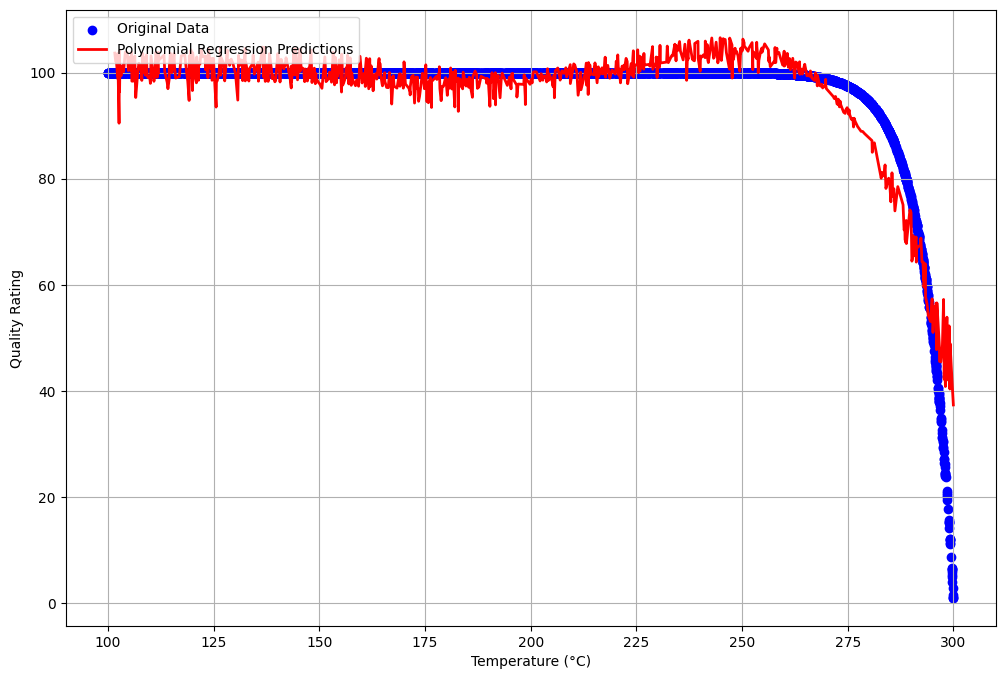

In [33]:
plt.figure(figsize= (12, 8))

sorted_X_test_indices = X_test.iloc[:, 0].argsort()
X_test_sorted = X_test.iloc[sorted_X_test_indices]

X_test_poly_sorted = poly.transform(X_test_sorted)
y_pred_sorted = lin_reg.predict(X_test_poly_sorted)

plt.scatter(X.iloc[:, 0], y, c='b', label='Original Data')
plt.plot(X_test_sorted.iloc[:, 0], y_pred_sorted, c='r', linewidth=2, label='Polynomial Regression Predictions')
plt.xlabel('Temperature (°C)')
plt.ylabel('Quality Rating', rotation = 90)
plt.legend(loc='upper left')
plt.grid()
plt.show()